In [1]:
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from gould_2026.estimator import  ArrayWithTime
from gould_2026.dimension_reduction.prosvd import proSVD
from gould_2026.stim_regressor import StimRegressor, StimAutoReg
from gould_2026.datasets import Daie21Dataset



In [49]:
output = None

In [2]:
d = Daie21Dataset()
neural_data = d.neural_data

stim = d.stimuli

In [3]:
pro = proSVD(k=2)
latents = pro.offline_run_on(neural_data)

In [4]:
sr1 = StimRegressor(error_on_missed_stim=False, stim_delay=2*latents.dt, log_level=2, heed_stimuli=False, attempt_correction=False)

sr2 = StimRegressor(error_on_missed_stim=False, stim_delay=2*latents.dt, log_level=2, heed_stimuli=True, attempt_correction=True)
sr2.stim_autoreg = StimAutoReg(n_steps_to_consider=7)
sr2.stim_reg.length_scales = np.array([2.98538262e-01, 8.91250938e-01, 2.37137371e-07])
sr2.stim_reg.reweight_every = np.inf


sr1.offline_run_on([(latents,'X'),(stim,'stim')])

stim_shifted = deepcopy(stim)
stim_shifted.t = stim_shifted.t - 2 * latents.dt
sr2.offline_run_on([(latents,'X'), (stim_shifted, 'stim')])

srs = {
    'blind': sr1,
    'reg': sr2,
}

/home/jgould/Documents/2026_paper/gould_2026/estimator.py:755: UserWarning: there should probably be an autonomous dynamics call here
  warnings.warn('there should probably be an autonomous dynamics call here')
/home/jgould/Documents/2026_paper/gould_2026/estimator.py:482: UserWarning: No outputs were routed to stream '0'.
  warnings.warn(f"No outputs were routed to stream '{convinient_return}'.")


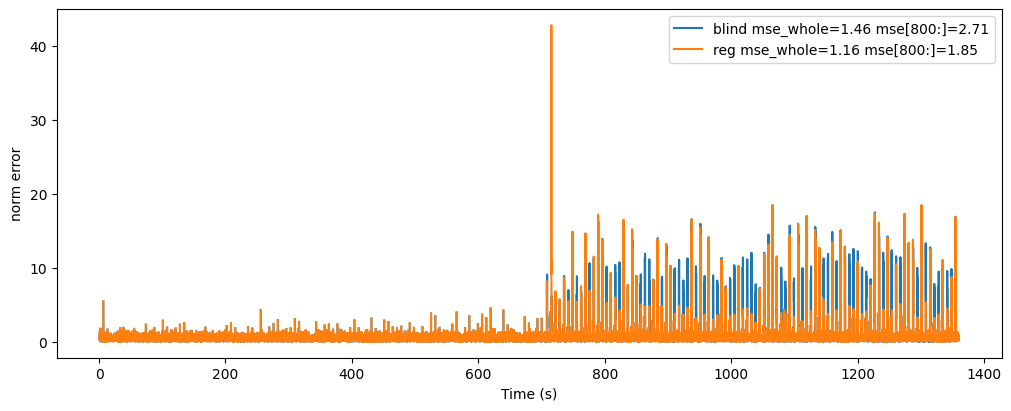

In [5]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(10,4))

for k, sr in srs.items():
    error = ArrayWithTime.from_list(sr.log['pred_error'], squeeze_type='to_2d')
    norm_error = ArrayWithTime(np.linalg.norm(error, axis=1),error.t)
    ax.plot(norm_error.t, norm_error, '-', label=f'{k} mse_whole={np.nanmean(norm_error ** 2):.2f} mse[800:]={np.nanmean(norm_error.slice_by_time(slice(800,None))** 2):.2f}')

ax.legend()

ax.set_xlabel('Time (s)')
ax.set_ylabel('norm error')

# for t in stim_shifted.t:
#     ax.axvline(t, color='red', alpha=0.3)

if output is not None:
    fig.savefig(output)



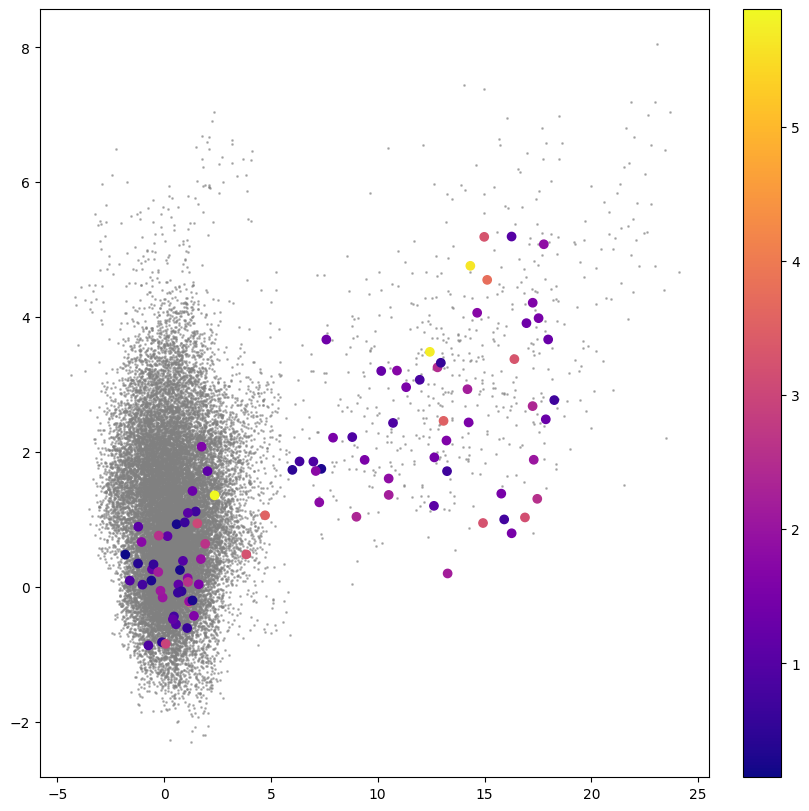

In [6]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(8,8))

preq_errors = ArrayWithTime.from_list(srs['reg'].stim_reg.log['preq_errors'], squeeze_type='to_2d')
preq_errors = np.linalg.norm(preq_errors,axis=1)
n_observed = srs['reg'].stim_reg.n_observed


ax.scatter(latents[:,0], latents[:,1], c='gray', alpha=0.5, s=1)
error_scatter = ax.scatter(srs['reg'].stim_reg.input_histories[0][:n_observed,0], srs['reg'].stim_reg.input_histories[0][:n_observed,1], c=preq_errors, cmap='plasma')
fig.colorbar(error_scatter)


Text(0, 0.5, 'latents')

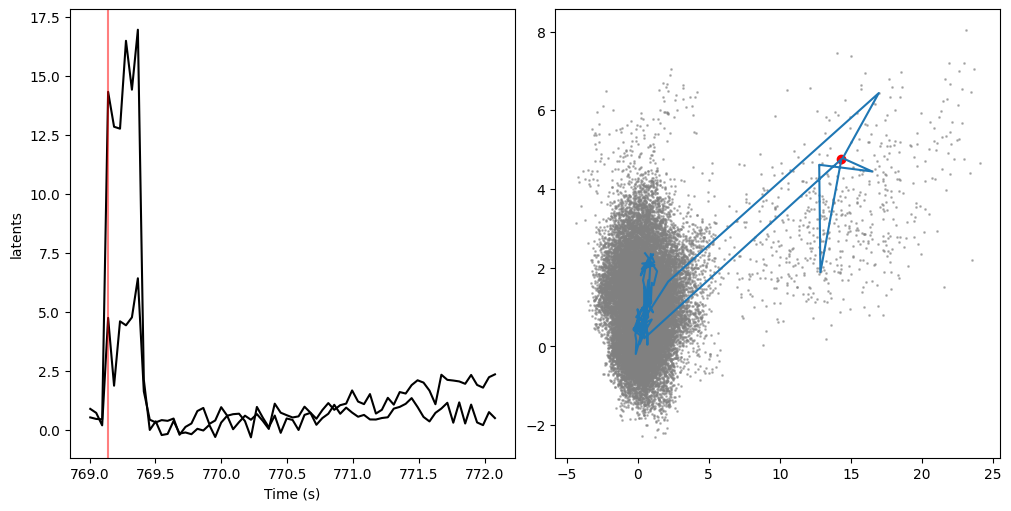

In [7]:

%matplotlib inline
fig, axs = plt.subplots(constrained_layout=True, figsize=(10,5), ncols=2)

n = 9
l = .1
r = 3
time_slice = slice(stim_shifted.t[n] -l, stim_shifted.t[n] + r)

ax = axs[1]
ax.scatter(latents[:,0], latents[:,1], c='gray', alpha=0.5, s=1)
# ax.plot(latents[:,0], latents[:,1], '-')
idx = np.argmin(np.linalg.norm(latents - srs['reg'].stim_reg.input_histories[0][0],axis=1))
idx = latents.time_to_sample(srs['reg'].stim_reg.input_histories[2][:n_observed, 0]) -1
latents_at_stims = latents.slice(idx).slice_by_time(time_slice)
ax.scatter(latents_at_stims[:,0], latents_at_stims[:,1], c='r')
latent_slice = latents.slice_by_time(time_slice)
ax.plot(latent_slice[:,0], latent_slice[:,1])

ax = axs[0]
ax.plot(latent_slice.t, latent_slice, 'k');
for t in latents_at_stims.t:
    ax.axvline(t, color='r', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('latents')
